# Import Library

In [1]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import normalize
from scipy.sparse import hstack, csr_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Load Dataset

In [2]:
df = pd.read_csv("dataset_preprocessing.csv", encoding="utf-8-sig")

print("Jumlah data :", len(df))
print(df["label"].value_counts())
df.head()

Jumlah data : 2136
label
1    1068
0    1068
Name: count, dtype: int64


,judul,isi,tanggal,sumber,url,label,skor_distorsi,kata_distorsi,text,case_folding,cleaning,tokenisasi,stopword,stemming
0,"Negara Tetangga RI Ini Geram, Grok X Punya Elo...",Malaysia yang merupakan negara tetangga Indone...,"Selasa, 06 Jan 2026 14:15 WIB",Detik.com,https://inet.detik.com/cyberlife/d-8294118/neg...,1,1,dimanipulasi,"Negara Tetangga RI Ini Geram, Grok X Punya Elo...","negara tetangga ri ini geram, grok x punya elo...",negara tetangga ri ini geram grok punya elon m...,"['negara', 'tetangga', 'ri', 'ini', 'geram', '...","['negara', 'tetangga', 'ri', 'geram', 'grok', ...",negara tetangga ri geram grok punya elon musk ...
1,Grab Bantah Rumor Bakal Hengkang dari Indonesia,"Liputan6.com, Jakarta -Grab Indonesiamembantah...",2026-06-03T21:00:15+07:00,Liputan6.com,https://www.liputan6.com/bisnis/read/7631475/g...,0,0,NaN,Grab Bantah Rumor Bakal Hengkang dari Indonesi...,grab bantah rumor bakal hengkang dari indonesi...,grab bantah rumor bakal hengkang dari indonesi...,"['grab', 'bantah', 'rumor', 'bakal', 'hengkang...","['grab', 'bantah', 'rumor', 'bakal', 'hengkang...",grab bantah rumor bakal hengkang com grab indo...
2,Pegawai Bea Cukai Akui Simpan Uang Suap Impor ...,"JAKARTA, KOMPAS.com-Pelaksana pemeriksa Kantor...","Kompas.com, 3 Juni 2026, 17:07 WIB",Kompas.com,https://nasional.kompas.com/read/2026/06/03/17...,0,0,NaN,Pegawai Bea Cukai Akui Simpan Uang Suap Impor ...,pegawai bea cukai akui simpan uang suap impor ...,pegawai bea cukai akui simpan uang suap impor ...,"['pegawai', 'bea', 'cukai', 'akui', 'simpan', ...","['pegawai', 'bea', 'cukai', 'akui', 'simpan', ...",pegawai bea cukai aku simpan uang suap impor b...
3,"Sejarah Hajat Laut Pangandaran, Tradisi Syukur...","PANGANDARAN, KOMPAS.com— Tradisi Hajat Laut ke...",2026-06-02T12:14:36+00:00,Kompas.com,https://bandung.kompas.com/read/2026/06/02/191...,0,0,NaN,"Sejarah Hajat Laut Pangandaran, Tradisi Syukur...","sejarah hajat laut pangandaran, tradisi syukur...",sejarah hajat laut pangandaran tradisi syukur ...,"['sejarah', 'hajat', 'laut', 'pangandaran', 't...","['sejarah', 'hajat', 'laut', 'pangandaran', 't...",sejarah hajat laut pangandaran tradisi syukur ...
4,Purbaya: Pelemahan IHSG hanya syok sesaat,Jakarta (ANTARA) - Menteri Keuangan (Menkeu) P...,2026-01-28T17:27:48+07:00,Antaranews.com,https://www.antaranews.com/berita/5381766/purb...,1,2,syok,Purbaya: Pelemahan IHSG hanya syok sesaat Jaka...,purbaya: pelemahan ihsg hanya syok sesaat jaka...,purbaya pelemahan ihsg hanya syok sesaat jakar...,"['purbaya', 'pelemahan', 'ihsg', 'hanya', 'syo...","['purbaya', 'pelemahan', 'ihsg', 'syok', 'sesa...",purbaya lemah ihsg syok saat menteri uang menk...


# Analisis Semantik

In [3]:
semantic_lexicon = {
    "hiperbolik": [
        "geger","heboh","gempar","dahsyat","mencekam","mengguncang",
        "menggemparkan","menghebohkan","mengerikan","menakutkan","mengejutkan",
        "bikin kaget","bikin heboh","bikin gempar","bikin geger","bikin merinding",
        "bikin takut","bikin panik","shocking","epik","dramatis",
        "mendadak","tiba-tiba","sontak","panik","kalang kabut","porak poranda",
        "kacau balau","amburadul","kacau","kisruh","ribut","rusuh","ricuh",
        "anarkis","kerusuhan","huru hara","huru-hara","kekacauan","kegaduhan","gaduh"
    ],
    "emosional": [
        "murka","berang","meradang","marah-marah","ngamuk","amuk","meluap",
        "meluap-luap","emosi","naik pitam","panas","memanas","gerah","geram",
        "sangat marah","kemarahan","terancam","menjerit","menangis","menggila",
        "ketakutan","ketakutan massal","panik massal","ancaman serius",
        "bahaya besar","bahaya mengancam","nyawa terancam","terancam punah",
        "waspada tinggi","siaga darurat","pengkhianat","pembohong","penipu",
        "koruptor","penjilat","boneka","badut","tukang bohong","tukang tipu",
        "tukang fitnah","fitnah","munafik","bangsat","brengsek"
    ],
    "provokatif": [
        "gagal total","gagal parah","tidak becus","tidak kompeten","tidak berguna",
        "tidak mampu","habis-habisan","tanpa ampun","paling parah","terburuk",
        "paling buruk","paling jelek","paling bodoh","paling korup","nihil prestasi",
        "nol prestasi","sia-sia","wajib tahu","syok","viral","terbongkar","terungkap",
        "terkuak","terekspos","membongkar","mengungkap","fakta mengejutkan",
        "fakta tersembunyi","fakta mencengangkan","netizen heboh","netizen geram",
        "netizen murka","semua orang","seluruh rakyat","seluruh warga",
        "sepanjang sejarah","sepanjang masa","pertama kali dalam sejarah",
        "direncanakan","rekayasa","skenario","disembunyikan","ditutupi","dimanipulasi",
        "ada yang mengatur","ada yang bermain","dalang","persekongkolan",
        "konspirasi","sabotase","nekat","nekad","biadab","buas","keji",
        "barbarian","tidak berperikemanusiaan"
    ],
    "bias": [
        "katanya","konon","kabarnya","disebut-sebut","diisukan","beredar",
        "diduga kuat","diduga keras","sumber terpercaya","orang dalam",
        "sumber internal","tanpa bukti","tanpa konfirmasi","tanpa verifikasi",
        "tersiar kabar","santer terdengar","berita bohong","berita palsu",
        "fake news","hoaks","hoax","sesat","menyesatkan","disesatkan",
        "ditipu","dibohongi","manipulasi informasi","distorsi informasi",
        "informasi menyesatkan","propaganda","pencucian otak"
    ],
}

def extract_semantic_features(teks):
    teks_lower = str(teks).lower()
    total_kata = max(len(teks_lower.split()), 1)
    skor = {}

    for kategori, kata_list in semantic_lexicon.items():
        kata_urut = sorted(kata_list, key=lambda x: len(x.split()), reverse=True)
        cocok = sum(
            1 for kata in kata_urut
            if re.search(r"\b" + re.escape(kata) + r"\b", teks_lower)
        )
        skor[f"skor_{kategori}"] = round(cocok / total_kata, 4)

    skor["skor_distorsi"] = round(
        skor.get("skor_hiperbolik", 0) * 0.25
        + skor.get("skor_emosional", 0) * 0.25
        + skor.get("skor_provokatif", 0) * 0.30
        + skor.get("skor_bias", 0) * 0.20,
        4,
    )
    return pd.Series(skor)

# Ekstraksi Fitur Semantik

In [4]:
print("Menghitung fitur semantik...")
semantic_df = df["stemming"].apply(extract_semantic_features)
X_sem_all   = normalize(csr_matrix(semantic_df.values.astype(float)))
print("Shape Semantik:", semantic_df.shape)

Menghitung fitur semantik...
Shape Semantik: (2136, 5)


# Split Data & TF-IDF

In [5]:
X_text = df["stemming"].fillna("").astype(str)
y      = df["label"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
)

print(f"Data Train : {X_train_text.shape[0]}")
print(f"Data Test  : {X_test_text.shape[0]}")

# Fit TF-IDF hanya dari data training
tfidf_model = TfidfVectorizer(
    max_features = 25000,
    ngram_range  = (1, 3),
    sublinear_tf = True,
    min_df       = 1,
)
X_train_tfidf = tfidf_model.fit_transform(X_train_text)
X_test_tfidf  = tfidf_model.transform(X_test_text)

joblib.dump(tfidf_model, "tfidf_model.pkl")
print("tfidf_model berhasil disimpan!")

# Ambil fitur semantik sesuai index train/test
X_sem_train = X_sem_all[X_train_text.index]
X_sem_test  = X_sem_all[X_test_text.index]

# Gabungkan TF-IDF + Semantik
X_train_combined = hstack([X_train_tfidf, X_sem_train])
X_test_combined  = hstack([X_test_tfidf,  X_sem_test])

print(f"Shape Train Combined : {X_train_combined.shape}")
print(f"Shape Test Combined  : {X_test_combined.shape}")

Data Train : 1708
Data Test  : 428
tfidf_model berhasil disimpan!
Shape Train Combined : (1708, 25005)
Shape Test Combined  : (428, 25005)


# Training Model

In [6]:
model = ComplementNB(alpha=0.1)
model.fit(X_train_combined, y_train)

y_pred = model.predict(X_test_combined)
print("Test Accuracy :", round(accuracy_score(y_test, y_pred) * 100, 2), "%")

Test Accuracy : 84.58 %


# Evaluasi Model

In [7]:
accuracy = accuracy_score(y_test, y_pred)

print("\n" + "="*50)
print(f"Test Accuracy : {round(accuracy * 100, 2)}%")
print("="*50)

print(classification_report(y_test, y_pred, target_names=["Normal", "Distorsi"]))


Test Accuracy : 84.58%
              precision    recall  f1-score   support

      Normal       0.86      0.83      0.84       214
    Distorsi       0.83      0.86      0.85       214

    accuracy                           0.85       428
   macro avg       0.85      0.85      0.85       428
weighted avg       0.85      0.85      0.85       428



# Visualisasi

Total data : 2136
Data train : 1708
Data test  : 428
label
1    1068
0    1068
Name: count, dtype: int64


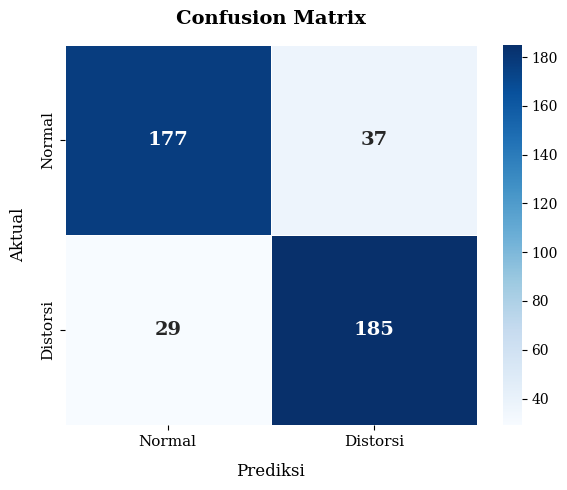

Disimpan: confusion_matrix.png


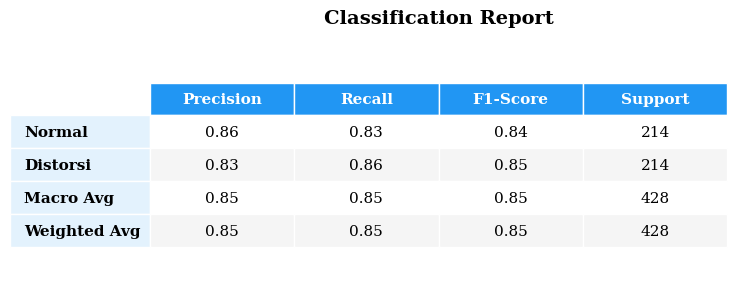

Disimpan: classification_report.png


In [8]:
cm = confusion_matrix(y_test, y_pred)

print(f"Total data : {len(df)}")
print(f"Data train : {X_train_text.shape[0]}")
print(f"Data test  : {X_test_text.shape[0]}")
print(df["label"].value_counts())

plt.rcParams.update({
    "font.family": "serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True, fmt="d", cmap="Blues",
    xticklabels=["Normal", "Distorsi"],
    yticklabels=["Normal", "Distorsi"],
    linewidths=0.5, linecolor="white",
    annot_kws={"size": 14, "weight": "bold"}, ax=ax
)
ax.set_xlabel("Prediksi", fontsize=12, labelpad=10)
ax.set_ylabel("Aktual", fontsize=12, labelpad=10)
ax.set_title("Confusion Matrix", fontsize=14, fontweight="bold", pad=15)
ax.tick_params(axis="both", labelsize=11)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Disimpan: confusion_matrix.png")

# Classification Report
report    = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df = report_df.loc[["0", "1", "macro avg", "weighted avg"]]
report_df.index = ["Normal", "Distorsi", "Macro Avg", "Weighted Avg"]
report_df = report_df[["precision", "recall", "f1-score", "support"]]
report_df[["precision", "recall", "f1-score"]] = report_df[["precision", "recall", "f1-score"]].round(2)
report_df["support"] = report_df["support"].astype(int).astype(str)

fig, ax = plt.subplots(figsize=(8, 3))
ax.axis("off")
table = ax.table(
    cellText=report_df.values,
    rowLabels=report_df.index,
    colLabels=["Precision", "Recall", "F1-Score", "Support"],
    cellLoc="center", loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.3, 2)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2196F3")
        cell.set_text_props(color="white", fontweight="bold")
    elif col == -1:
        cell.set_facecolor("#E3F2FD")
        cell.set_text_props(fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#F5F5F5")
    cell.set_edgecolor("white")
ax.set_title("Classification Report", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("classification_report.png", dpi=150, bbox_inches="tight")
plt.show()
print("Disimpan: classification_report.png")

# Simpan Model

In [9]:
joblib.dump(model, "model_distorsi.pkl")
print("Model berhasil disimpan!")

Model berhasil disimpan!
